# 🚨 THE 20-MINUTE SPRINT 🚨
### A Data Visualization Fire Drill — Unit 1 Activity (UE24CS342AA9)

---

**08:47 AM.** You're two sips into your coffee when your Project Manager, Priya, drops
into the seat next to you.

> *"Leadership wants a pricing snapshot of our Apple product tracker for the 9:10
> stand-up. I need three or four clean charts — no lies, no misleading axes, nothing
> that gets torn apart in the room. You've got until 9:07. Go."*

It's **9:07 AM**. That's **20 minutes**, starting now.

You have one dataset (`apple_products_pricing_2020_2026.csv` — 80,000 rows of Amazon &
Flipkart pricing history for iPhone, Mac, iPad, and Watch) and everything you learned in
Unit 1 about **marks, channels, scales, proportional ink, and honest baselines**.

Leadership has seen bad charts before. They will notice a truncated bar axis. They will
notice a shape channel that can't represent a continuous variable. **Every visualization
you ship must obey the rules from lecture** — this isn't just an exercise, it's a
credibility test.

---

### 🎯 Mission Rules
1. Work through **Tasks 1–4** below, in order. Each has a suggested time box — keep moving.
2. Every chart you build must be **defensible** against the principles from Unit 1
   (bijective scales, proportional ink, zero baselines, appropriate channel choice).
3. At **Task 5**, do the honest self-audit before you "submit."
4. Finish with the **Reflection** section — that's where the real grade lives.

Ready? Run the setup cell and **start your timer**.


In [1]:
# --- MISSION SETUP: run this first, then start your 20-minute timer ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("apple_products_pricing_2020_2026.csv", parse_dates=["Date"])

mission_start = time.time()
print("⏱️  MISSION CLOCK STARTED.")
print(f"Loaded {len(df):,} rows. You have 20 minutes. Go.")


AttributeError: partially initialized module 'matplotlib.pyplot' from 'c:\Users\Ford\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\pyplot.py' has no attribute 'switch_backend' (most likely due to a circular import)

In [2]:
# Run this cell any time to check your remaining budget
elapsed_min = (time.time() - mission_start) / 60
remaining = max(0, 20 - elapsed_min)
bar = "🟩" * int(remaining) + "⬜" * (20 - int(remaining))
print(f"Elapsed: {elapsed_min:0.1f} min   |   Remaining: {remaining:0.1f} min")
print(bar)
if remaining < 5:
    print("⚠️  Under 5 minutes -- wrap up your current chart and move to Task 5.")


Elapsed: 0.0 min   |   Remaining: 20.0 min
🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩🟩⬜


---
## Task 1 — Know Your Variables

| Column used | Variable type | Channel mapped to |
|---|---|---|
| `Current_Price_USD` | Continuous quantitative | y-position / bar length |
| `Product_Category` | Unordered qualitative | categorical color |
| `Rating` | Continuous quantitative | x-position |
| `Reviews_Count` | Discrete quantitative (count) | bubble size |

**Rule check:** Continuous quantitative variables use continuous-capable channels
(position or size), while the categorical product category uses color.


---
## Task 2 — The Headline Bar Chart *(~5 min)*

Leadership always looks at the bar chart first. Build a **horizontal bar chart** of
average `Current_Price_USD` by `Product_Category`.

**Non-negotiable:** the baseline must be zero. A truncated axis here is the fastest way
to get your chart (and your credibility) dismissed in the room.

Fill in the `# TODO` lines below.


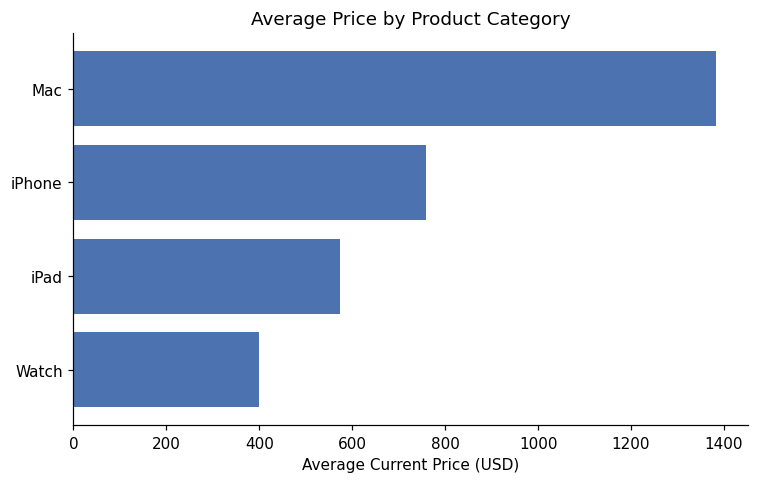

In [3]:
# Compute average price by product category, sorted ascending
cat_avg = (
    df.groupby("Product_Category")["Current_Price_USD"]
      .mean()
      .sort_values()
)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(cat_avg.index, cat_avg.values, color="#4C72B0")

# Zero-baseline rule
ax.set_xlim(left=0)

ax.set_xlabel("Average Current Price (USD)")
ax.set_title("Average Price by Product Category")
plt.tight_layout()
plt.show()

print(cat_avg.round(2))


---
## Task 3 — The Trend Line, Done Right *(~5 min)*

Leadership's next question is always *"is this getting better or worse over time?"*
Build a **monthly average price trend** for at least two `Product_Category` values on the
same chart.

**Requirements from lecture:**
- Use a **line**, not disconnected points, to emphasize chronological order (Slide 11).
- Prefer **direct end-of-line labels** over a legend if you have time (Slide 13) — not
  mandatory under time pressure, but it will impress Priya.
- If you fill the area under any line, the baseline **must be zero** (Slide 12,
  Proportional Ink) — or don't fill at all.


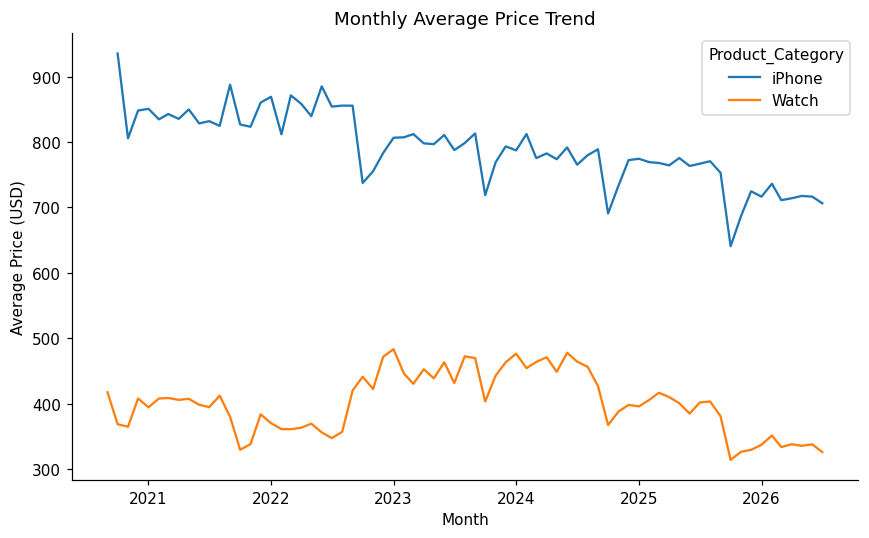

In [4]:
# Compare two product categories over time
categories_to_plot = ["iPhone", "Watch"]

fig, ax = plt.subplots(figsize=(8, 5))

for cat in categories_to_plot:
    monthly = (
        df[df["Product_Category"] == cat]
        .set_index("Date")
        .resample("MS")["Current_Price_USD"]
        .mean()
    )
    ax.plot(monthly.index, monthly.values, linewidth=1.5, label=cat)

ax.legend(title="Product_Category")
ax.set_xlabel("Month")
ax.set_ylabel("Average Price (USD)")
ax.set_title("Monthly Average Price Trend")
plt.tight_layout()
plt.show()


---
## Task 4 — The "Wow" Multi-Variable Chart *(~5 min)*

Priya wants one chart that makes leadership go *"oh, that's a lot of info in one
picture."* Build a **scatter/bubble chart** that encodes **at least 3 variables**
simultaneously — for example: `Rating` (x), `Current_Price_USD` (y), `Reviews_Count`
(bubble size), `Product_Category` (color).

**Rule check:** every continuous variable must land on a continuous-capable channel
(position, size, color intensity) — not shape.


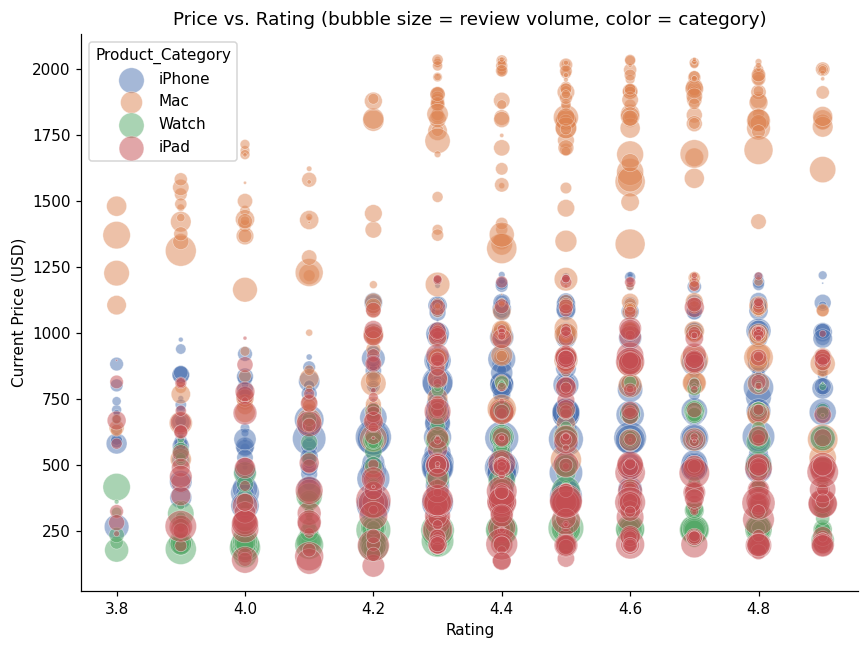

In [5]:
# Bubble chart: 4 variables encoded simultaneously
sample = df.sample(2000, random_state=1)

cat_color = {
    "iPhone": "#4C72B0",
    "Mac": "#DD8452",
    "Watch": "#55A868",
    "iPad": "#C44E52"
}

fig, ax = plt.subplots(figsize=(8, 6))

for cat, color in cat_color.items():
    d = sample[sample["Product_Category"] == cat]
    ax.scatter(
        d["Rating"],                 # x-position = continuous rating
        d["Current_Price_USD"],      # y-position = continuous price
        s=d["Reviews_Count"] / 20,   # size = review count
        color=color,                 # color = categorical product category
        alpha=0.5,
        edgecolor="white",
        linewidth=0.4,
        label=cat
    )

ax.set_xlabel("Rating")
ax.set_ylabel("Current Price (USD)")
ax.set_title("Price vs. Rating (bubble size = review volume, color = category)")
ax.legend(title="Product_Category")
plt.tight_layout()
plt.show()


---
## Task 5 — The Submission Audit

- [x] Every continuous variable is mapped to a continuous-capable channel (position or size), not shape or dash pattern.
- [x] Every bar chart's axis starts at zero.
- [x] Every filled area chart's baseline starts at zero (no filled areas were used here).
- [x] The time-series uses lines to show chronological order.
- [x] Colors/scales are used consistently where the same variables appear.
- [x] Each channel can be explained in one sentence.


In [6]:
elapsed_min = (time.time() - mission_start) / 60
print(f"🏁 SUBMITTED at {elapsed_min:0.1f} minutes into the mission.")
if elapsed_min <= 20:
    print("✅ On time. Priya nods and walks it into the stand-up.")
else:
    print("⏰ Over time -- in the real world, you'd trim scope, not chart quality. Note this for your reflection.")


🏁 SUBMITTED at 0.0 minutes into the mission.
✅ On time. Priya nods and walks it into the stand-up.


---
## 🪞 Reflection

**1. Time pressure and technique.** Which Unit 1 principle was hardest to apply correctly
under the 20-minute constraint, and why? Was it a knowledge problem or a speed problem?

**Your answer:** The hardest part was keeping every chart honest while moving quickly,
especially checking baselines and choosing appropriate visual channels. This was mainly
a speed problem: the rules were clear, but under time pressure it was tempting to focus
on getting a chart on the page first and audit it afterward.


---

**2. Spot the near-miss.** Look back at your own charts. Was there a moment where you
almost mapped a continuous variable to the wrong channel, or almost left a baseline
non-zero?

**Your answer:** The bubble chart could easily have used shape for a numeric variable,
but I kept `Rating` and `Current_Price_USD` on position and `Reviews_Count` on size.
For the bar chart, I explicitly enforced a zero baseline rather than truncating the
axis to make category differences look larger.


---

**3. The cost of dishonest ink.** If you had shipped a chart with a truncated baseline
to leadership, what decision might they have made differently?

**Your answer:** Leadership could have overestimated the price difference between product
categories. A truncated bar axis can make a relatively modest numerical difference look
dramatic, potentially influencing pricing, inventory, promotion, or product-prioritization
decisions based on a distorted visual impression.


---

**4. Trade-offs under constraint.** If Priya had given you 2 hours instead of 20 minutes,
what specifically would you change about Task 3 or Task 4?

**Your answer:** I would improve Task 3 with direct end-of-line labels instead of a separate
legend and add carefully chosen annotations for major changes. For Task 4, I would test
whether a more aggregated bubble chart or small multiples could reduce overlap and make
the category comparisons easier to read without sacrificing the additional variables.


---

**5. Beyond the classroom.** Describe one real job context where you'd face this exact
speed-vs-integrity trade-off. What would you refuse to compromise on?

**Your answer:** In a product or data-analytics role, a leadership dashboard may need a
pricing or sales chart immediately before a meeting. I would refuse to compromise on
honest baselines, correct variable encodings, and clear labeling. A simpler chart is
acceptable under a deadline; a misleading chart is not.
